In [90]:
# Step 1: Import necessary libraries with additional ones for improvements
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from prophet import Prophet
import numpy as np
import warnings
import os
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, f1_score
import holidays
from prophet import Prophet

warnings.filterwarnings("ignore")

# Create the output directory if it doesn't exist
output_dir = "ER_Prophet_Results"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Function to save text results to a file
def save_text_to_file(filename, content):
    """Saves text content to a file in the output directory."""
    filepath = os.path.join(output_dir, filename)
    with open(filepath, 'w', encoding='utf-8') as f:
        f.write(content)

# Function to reverse Hebrew text while preserving non-Hebrew parts
def reverse_hebrew(text):
    """Reverses Hebrew text in room-requirement labels while keeping room names intact."""
    def is_hebrew(char):
        return '\u0590' <= char <= '\u05FF'
    parts = text.split('_in_')
    if len(parts) != 2:
        return text
    hebrew_part = parts[0]
    room_part = parts[1]
    reversed_hebrew = ''.join(char if not is_hebrew(char) else char for char in hebrew_part[::-1])
    return f"{reversed_hebrew}_in_{room_part}"

# Add Israeli holidays
class IsraeliHolidays(holidays.HolidayBase):
    def _populate(self, year):
        # Add Israeli holidays - this is a simplified version, you may need to add more
        self[pd.Timestamp(year, 4, 15)] = "Passover"  # Approximate date
        self[pd.Timestamp(year, 4, 21)] = "Last day of Passover"  # Approximate date
        self[pd.Timestamp(year, 5, 9)] = "Independence Day"  # Approximate date
        self[pd.Timestamp(year, 9, 25)] = "Rosh Hashanah"  # Approximate date
        self[pd.Timestamp(year, 10, 4)] = "Yom Kippur"  # Approximate date
        self[pd.Timestamp(year, 10, 9)] = "Sukkot"  # Approximate date
        self[pd.Timestamp(year, 10, 16)] = "Simchat Torah"  # Approximate date
        self[pd.Timestamp(year, 12, 7)] = "Hanukkah"  # Approximate date

# Create Israeli holidays object
israeli_holidays = IsraeliHolidays()

In [91]:
# Step 2: Load the dataset
file_path = 'ED_pattern_rooms_only.csv'
df = pd.read_csv(file_path, parse_dates=['timestamp'])
df.set_index('timestamp', inplace=True)

In [92]:
# Step 3: Filter for 'required' status and specific rooms
pattern_rooms = ['A101', 'A102', 'A103', 'A104', 'A105', 'A106', 'A107', 'A108', 'A109', 'A110',
                 'A111', 'A112', 'A113', 'A114', 'A115', 'A116', 'A117', 'B201', 'B202', 'B203',
                 'B204', 'B205', 'B206', 'B207', 'B208', 'B209', 'B210', 'B211', 'B212', 'B213',
                 'B214', 'B215', 'B216', 'B217', 'C301', 'C302', 'C303', 'C304', 'C305', 'C306',
                 'C307', 'C308', 'C309', 'C310', 'C311', 'C312', 'C313', 'C314', 'C315', 'C316',
                 'C317', 'C318', 'C319', 'C320', 'C321', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6']
df_required = df[df['status'] == 'required']
df_required = df_required[df_required['room'].isin(pattern_rooms)]

In [93]:
# Step 4: Add exogenous variables including Israeli holidays
df_required.index = df_required.index.tz_localize(None)  # Remove timezone for compatibility
df_required['day_of_week'] = df_required.index.day_name()
df_required['hour_of_day'] = df_required.index.hour  # Add hour of day feature
df_required['is_holiday'] = df_required.index.map(lambda dt: dt in israeli_holidays).astype(int)
df_required['is_weekend'] = df_required.index.dayofweek.isin([4, 5]).astype(int)  # Friday/Saturday for Israel

# Print debug information
print("Debugging df_required:")
print(f"Shape of df_required: {df_required.shape}")
print(f"Date range of df_required: {df_required.index.min()} to {df_required.index.max()}")
print(f"Unique rooms in df_required: {df_required['room'].unique()}")
print(f"Unique requirements in df_required: {df_required['requirement'].unique()}")

# Identify unique requirements
unique_requirements = df_required['requirement'].unique()
print(f"Number of unique requirements: {len(unique_requirements)}")
print(f"First 5 unique requirements: {unique_requirements[:5]}")

# Standardize room and requirement values
df_required['room'] = df_required['room'].str.strip().str.upper()
df_required['requirement'] = df_required['requirement'].str.strip()

# Create time series dictionary for each room (aggregated across all requirements)
time_series_dict = {}
last_complete_date = pd.Timestamp('2025-01-31')  # actual last date

for room in pattern_rooms:
    subset = df_required[df_required['room'] == room]
    if not subset.empty:
        # Group by day and sum all requirements for the room
        daily_counts = subset.resample('D').size()
        time_series_dict[room] = daily_counts
        print(f"Created series for room {room}: {len(daily_counts)} days, {(daily_counts > 0).sum()} non-zero days")
    else:
        print(f"No data for room {room}")

Debugging df_required:
Shape of df_required: (109559, 11)
Date range of df_required: 2024-07-01 00:00:20.450963 to 2025-01-23 10:14:01.423535
Unique rooms in df_required: ['B205' 'B217' 'B206' 'B215' 'A104' 'C305' 'B216' 'A106' 'A111' 'C303'
 'A116' 'A113' 'A112' 'B201' 'C311' 'A107' 'A103' 'A108' 'C314' 'C310'
 'A109' 'B209' 'A115' 'A101' 'B211' 'A105' 'A110' 'A102' 'B203' 'T1'
 'B212' 'B202' 'C308' 'B208' 'A114' 'B214' 'T3' 'B213' 'C320' 'T4' 'B204'
 'C309' 'C315' 'C318' 'C307' 'C306' 'C316' 'C319' 'B207' 'B210' 'A117'
 'C313' 'C312' 'T2' 'C304' 'C301' 'C317' 'C302' 'C321' 'T5' 'T6']
Unique requirements in df_required: ['ניקיון تنظيف' 'יעוץ' 'תפוס' 'בדיקת דם' 'בדיקת אק"ג'
 'כח עזר - סיוע למטופל' 'כח עזר - שונות' 'כח עזר - אוכל' 'כביסה' 'צר"פ'
 'נקיון - החלפת פרגוד' 'נקיון - בידוד' 'בדיקת רופא']
Number of unique requirements: 13
First 5 unique requirements: ['ניקיון تنظيف' 'יעוץ' 'תפוס' 'בדיקת דם' 'בדיקת אק"ג']
Created series for room A101: 207 days, 207 non-zero days
Created series f

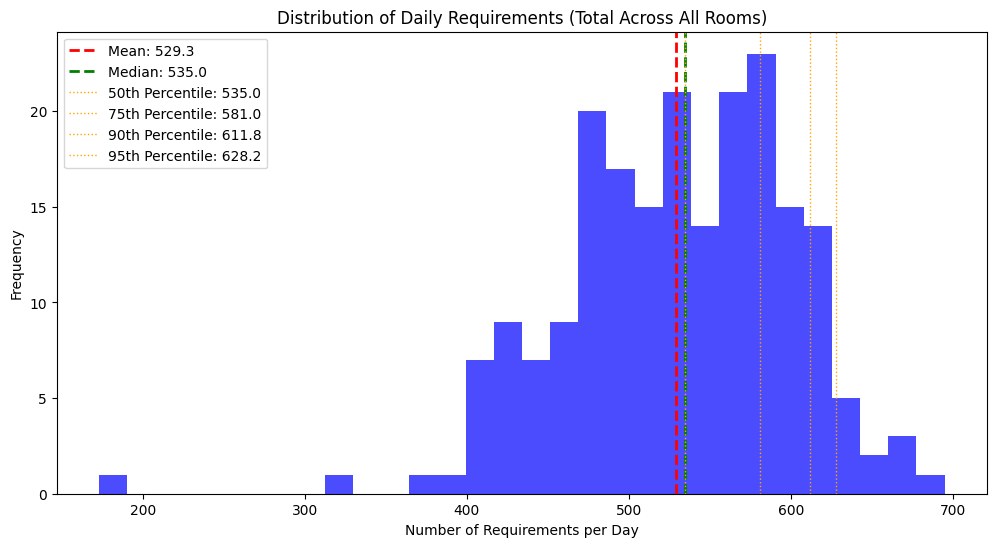

Daily Requirements Distribution Metrics:
Mean: 529.3
Median: 535.0
Standard Deviation: 70.9
90th Percentile: 611.8
95th Percentile: 628.2
Maximum: 695.0


In [94]:
# Step 5: Visualize daily distribution of requirements to understand variability
df_required_truncated = df_required[df_required.index <= last_complete_date]
total_demand = df_required_truncated.resample('D').size().fillna(0)

plt.figure(figsize=(12, 6))
plt.hist(total_demand, bins=30, alpha=0.7, color='blue')
plt.axvline(total_demand.mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {total_demand.mean():.1f}')
plt.axvline(total_demand.median(), color='green', linestyle='dashed', linewidth=2, label=f'Median: {total_demand.median():.1f}')
percentiles = [50, 75, 90, 95]
percentile_values = [total_demand.quantile(p/100) for p in percentiles]
for p, val in zip(percentiles, percentile_values):
    plt.axvline(val, color='orange', linestyle=':', linewidth=1, label=f'{p}th Percentile: {val:.1f}')
plt.title("Distribution of Daily Requirements (Total Across All Rooms)")
plt.xlabel("Number of Requirements per Day")
plt.ylabel("Frequency")
plt.legend()
plt.savefig(os.path.join(output_dir, "daily_requirements_distribution.png"))
plt.show()

# Output key distribution metrics
print(f"Daily Requirements Distribution Metrics:")
print(f"Mean: {total_demand.mean():.1f}")
print(f"Median: {total_demand.median():.1f}")
print(f"Standard Deviation: {total_demand.std():.1f}")
print(f"90th Percentile: {total_demand.quantile(0.9):.1f}")
print(f"95th Percentile: {total_demand.quantile(0.95):.1f}")
print(f"Maximum: {total_demand.max():.1f}")

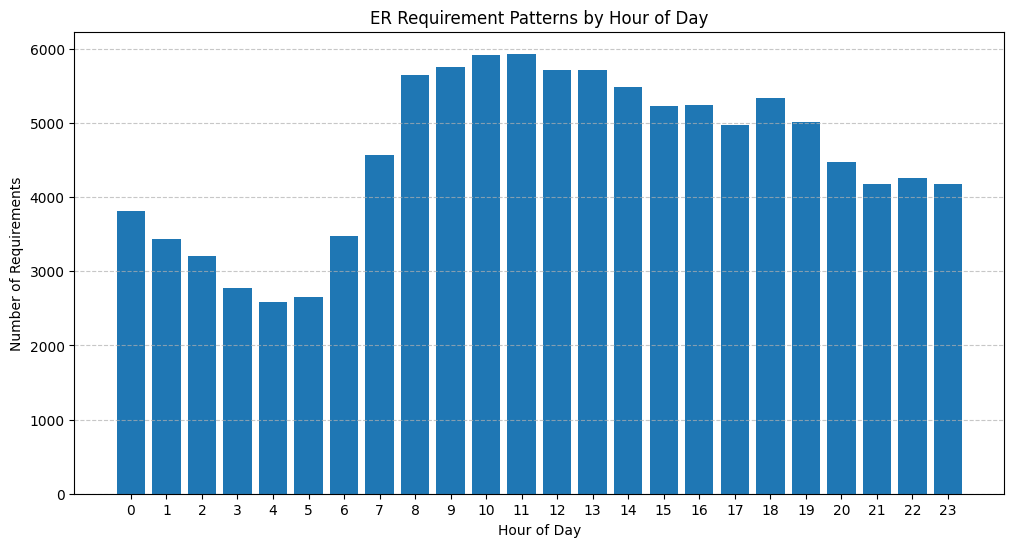

In [95]:
# Step 6: Create hour-of-day patterns to understand intraday variability
hourly_pattern = df_required_truncated.groupby(df_required_truncated.index.hour).size()
plt.figure(figsize=(12, 6))
plt.bar(hourly_pattern.index, hourly_pattern.values)
plt.title("ER Requirement Patterns by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Requirements")
plt.xticks(range(24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(output_dir, "hourly_requirement_pattern.png"))
plt.show()

In [96]:
# Step 7: Enhanced Outlier Detection with Percentile-Based Thresholds
def detect_outliers(series, low_percentile=0.05, high_percentile=0.95):
    """Detect outliers based on percentiles, better for non-normal distributions."""
    low_threshold = series.quantile(low_percentile)
    high_threshold = series.quantile(high_percentile)
    outliers = pd.Series(0, index=series.index)
    outliers[series < low_threshold] = -1  # Low outliers
    outliers[series > high_threshold] = 1   # High outliers
    return outliers

# Apply improved outlier detection
time_series_dict_truncated = {key: series[series.index <= last_complete_date]
                             for key, series in time_series_dict.items()}

all_outliers = {}
for series_key, series in time_series_dict_truncated.items():
    if len(series) > 10 and series.sum() > 10:  # Only analyze series with enough data
        outliers = detect_outliers(series)
        if outliers.abs().sum() > 0:
            all_outliers[series_key] = outliers

total_outliers = detect_outliers(total_demand)
if total_outliers.abs().sum() > 0:
    all_outliers['total_demand'] = total_outliers

# Define a function to preprocess time series data
def preprocess_time_series(series):
    clean_series = series.fillna(method='ffill').fillna(method='bfill').fillna(0)
    return clean_series

# Align all series to the correct date range: July 1, 2024, to January 23, 2025
date_range = pd.date_range(start='2024-07-01', end='2025-01-23', freq='D')
time_series_dict_aligned = {key: series.reindex(date_range, fill_value=0)
                           for key, series in time_series_dict_truncated.items()}

In [97]:
# Step 8: Improved time series modeling with Prophet
from prophet import Prophet
import matplotlib.pyplot as plt

# Define future dates globally (used across functions)
last_complete_date = pd.Timestamp('2025-01-23')
future_dates = pd.date_range(start=last_complete_date + pd.Timedelta(days=1), periods=30, freq='D')

# Function to plot train, test, and prediction data
def plot_room_forecast(room, forecast_result, time_series, output_dir):
    plt.figure(figsize=(15, 6))

    # Plot historical training data
    plt.plot(forecast_result['train_dates'], forecast_result['train_actual'], label='Training Data', color='blue')

    # Plot test predictions (historical forecast)
    plt.plot(forecast_result['train_dates'], forecast_result['test_predictions'], label='Test Predictions', color='orange')

    # Plot future predictions
    plt.plot(forecast_result['future_predictions'].index, forecast_result['future_predictions'], label='Future Predictions', color='green')

    # Add historical 95th percentile
    hist_95 = time_series.quantile(0.95)
    plt.axhline(hist_95, color='red', linestyle='--', label=f'Historical 95th Percentile: {hist_95:.1f}')

    # Add future 95th percentile
    future_95 = forecast_result['future_predictions'].quantile(0.95)
    plt.axhline(future_95, color='purple', linestyle='--', label=f'Future 95th Percentile: {future_95:.1f}')

    plt.title(f"Staffing Demand Forecast for Room {room}")
    plt.xlabel("Date")
    plt.ylabel("Number of Requirements")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.savefig(os.path.join(output_dir, f"{room}_forecast.png"))
    plt.close()

# Function to train Prophet model
def train_prophet(series_key, series):
    # Preprocess series
    series = preprocess_time_series(series)
    num_days = len(series)
    num_non_zero_days = (series > 0).sum()

    # Relaxed condition: Skip if fewer than 30 non-zero days
    if num_days < 30 or num_non_zero_days < 30:
        return None, f"Skipping {series_key}: Not enough data (days={num_days}, non-zero days={num_non_zero_days})"

    # Prepare data for Prophet
    df = pd.DataFrame({'ds': series.index, 'y': series.values})

    # Initialize and configure Prophet
    model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_prior_scale=15.0,  # More seasonal flexibility
    changepoint_prior_scale=0.1    # More trend flexibility
)
    model.add_country_holidays(country_name='IL')  # Add Israeli holidays

    # Fit the model
    try:
        model.fit(df)
    except Exception as e:
        return None, f"Skipping {series_key}: Prophet failed to fit model ({str(e)})"

    # Generate future predictions
    future = model.make_future_dataframe(periods=30)
    forecast = model.predict(future)
    future_predictions = forecast['yhat'].tail(30)

    # Apply floor, cap, and round predictions
    historical_max = series.max()
    future_predictions = future_predictions.clip(lower=0, upper=historical_max * 1.5)  # Cap at 1.5x historical max
    future_predictions = future_predictions.round().astype(int)  # Round to integers

    # Use historical predictions for validation (test set)
    historical_forecast = model.predict(df)
    test_predictions = historical_forecast['yhat'].values

    # Package results
    result = {
        'future_predictions': pd.Series(future_predictions.values, index=future_dates),
        'test_predictions': test_predictions,
        'train_dates': df['ds'],
        'train_actual': df['y'],
        'model': model
    }

    # Debug: Print historical max and first few predictions for validation
    print(f"Room {series_key}: Historical Max = {historical_max:.1f}, First 5 future predictions = {future_predictions.values[:5]}")

    return result, None

# Train Prophet models for each room
forecast_results = {}
skipped_series = []

# Use time_series_dict_aligned
for series_key, series in time_series_dict_aligned.items():
    result, skip_reason = train_prophet(series_key, series)
    if result:
        forecast_results[series_key] = result
        plot_room_forecast(series_key, result, time_series_dict[series_key], output_dir)
    else:
        skipped_series.append(skip_reason)

# Log skipped series
if skipped_series:
    print("Skipped series due to insufficient data:")
    for reason in skipped_series:
        print(f"- {reason}")

DEBUG:cmdstanpy:input tempfile: /tmp/tmp5aqnif_r/k9cd6s7n.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5aqnif_r/28_evwz0.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=57393', 'data', 'file=/tmp/tmp5aqnif_r/k9cd6s7n.json', 'init=/tmp/tmp5aqnif_r/28_evwz0.json', 'output', 'file=/tmp/tmp5aqnif_r/prophet_modeledg_m5c6/prophet_model-20250408143322.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
14:33:22 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
14:33:22 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Room A101: Historical Max = 25.0, First 5 future predictions = [11 11 13 11 12]


DEBUG:cmdstanpy:input tempfile: /tmp/tmp5aqnif_r/ynq6zx6g.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5aqnif_r/0y2q97j8.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=82420', 'data', 'file=/tmp/tmp5aqnif_r/ynq6zx6g.json', 'init=/tmp/tmp5aqnif_r/0y2q97j8.json', 'output', 'file=/tmp/tmp5aqnif_r/prophet_model85cmimrr/prophet_model-20250408143322.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
14:33:22 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
14:33:22 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Room A102: Historical Max = 26.0, First 5 future predictions = [13 12 16 14 15]


DEBUG:cmdstanpy:input tempfile: /tmp/tmp5aqnif_r/7grop62z.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5aqnif_r/dpseh37w.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=60188', 'data', 'file=/tmp/tmp5aqnif_r/7grop62z.json', 'init=/tmp/tmp5aqnif_r/dpseh37w.json', 'output', 'file=/tmp/tmp5aqnif_r/prophet_modelb1689ekk/prophet_model-20250408143323.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
14:33:23 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
14:33:23 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


...

Room T3: Historical Max = 9.0, First 5 future predictions = [0 0 0 0 0]


DEBUG:cmdstanpy:input tempfile: /tmp/tmp5aqnif_r/4x9vv5eo.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5aqnif_r/fl3gnkgl.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=55071', 'data', 'file=/tmp/tmp5aqnif_r/4x9vv5eo.json', 'init=/tmp/tmp5aqnif_r/fl3gnkgl.json', 'output', 'file=/tmp/tmp5aqnif_r/prophet_model4jddi1g9/prophet_model-20250408143357.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
14:33:57 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
14:33:57 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Room T4: Historical Max = 6.0, First 5 future predictions = [0 0 0 0 0]


DEBUG:cmdstanpy:input tempfile: /tmp/tmp5aqnif_r/qfh4ik0h.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp5aqnif_r/ijm03wpc.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=41414', 'data', 'file=/tmp/tmp5aqnif_r/qfh4ik0h.json', 'init=/tmp/tmp5aqnif_r/ijm03wpc.json', 'output', 'file=/tmp/tmp5aqnif_r/prophet_modelauus5ltg/prophet_model-20250408143357.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
14:33:57 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
14:33:57 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Room T5: Historical Max = 9.0, First 5 future predictions = [0 0 0 0 0]
Skipped series due to insufficient data:
- Skipping T6: Not enough data (days=207, non-zero days=9)


In [98]:
# Step 9: Analyze peak demand patterns (critical for ER)
# Identify 95th percentile days for each room
peak_demand_days = {}
for room, series in time_series_dict.items():
    threshold = series.quantile(0.95)
    peak_days = series[series >= threshold].index
    peak_demand_days[room] = peak_days
    print(f"Room {room}: {len(peak_days)} peak demand days (95th percentile = {threshold:.1f})")

Room A101: 17 peak demand days (95th percentile = 19.0)
Room A102: 19 peak demand days (95th percentile = 19.0)
Room A103: 13 peak demand days (95th percentile = 21.0)
Room A104: 11 peak demand days (95th percentile = 21.7)
Room A105: 15 peak demand days (95th percentile = 20.0)
Room A106: 16 peak demand days (95th percentile = 19.0)
Room A107: 12 peak demand days (95th percentile = 19.0)
Room A108: 11 peak demand days (95th percentile = 18.7)
Room A109: 16 peak demand days (95th percentile = 18.0)
Room A110: 15 peak demand days (95th percentile = 19.0)
Room A111: 11 peak demand days (95th percentile = 18.7)
Room A112: 13 peak demand days (95th percentile = 21.0)
Room A113: 13 peak demand days (95th percentile = 20.0)
Room A114: 13 peak demand days (95th percentile = 20.0)
Room A115: 16 peak demand days (95th percentile = 20.0)
Room A116: 15 peak demand days (95th percentile = 21.0)
Room A117: 11 peak demand days (95th percentile = 18.7)
Room B201: 11 peak demand days (95th percentile 

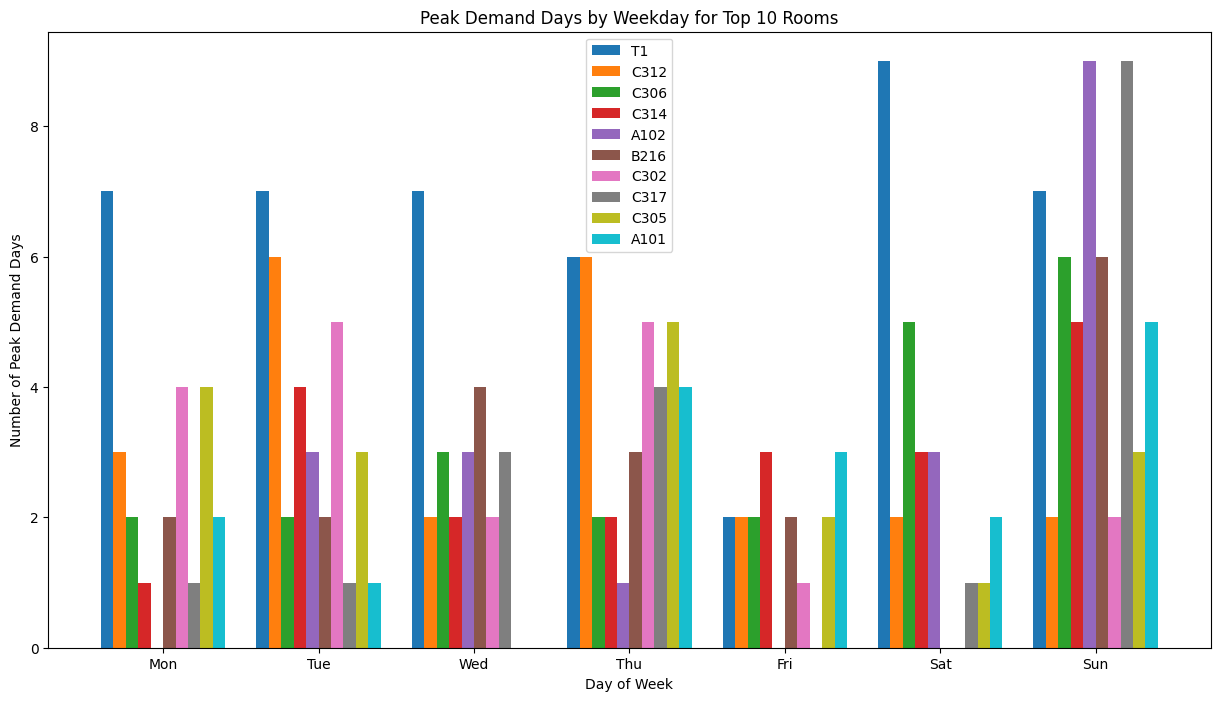

In [99]:
# Step 10: Visualize room-specific peak demand patterns by weekday
peak_by_weekday = {room: [0] * 7 for room in pattern_rooms}
for room, peak_days in peak_demand_days.items():
    for day in peak_days:
        weekday = day.dayofweek
        peak_by_weekday[room][weekday] += 1

# Plot weekday patterns for top 10 rooms with most peak days
top_rooms = sorted(pattern_rooms,
                   key=lambda r: sum(peak_by_weekday[r]) if r in peak_by_weekday else 0,
                   reverse=True)[:10]

plt.figure(figsize=(15, 8))
width = 0.08
weekdays = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

for i, room in enumerate(top_rooms):
    plt.bar([x + i*width for x in range(7)],
            peak_by_weekday[room],
            width=width,
            label=room)

plt.xlabel('Day of Week')
plt.ylabel('Number of Peak Demand Days')
plt.title('Peak Demand Days by Weekday for Top 10 Rooms')
plt.xticks([x + width*4.5 for x in range(7)], weekdays)
plt.legend()
plt.savefig(os.path.join(output_dir, "peak_demand_by_weekday.png"))
plt.show()

In [100]:
# Step 11: Generate peak demand forecasts (critical for ER planning)
def generate_peak_demand_forecast(room):
    if room not in time_series_dict:
        return None

    # Historical peak demand
    historical_daily_totals = time_series_dict[room]
    historical_peak = historical_daily_totals.quantile(0.95)

    # Future peak demand
    future_dates = pd.date_range(start=last_complete_date + pd.Timedelta(days=1), periods=30, freq='D')
    future_daily_totals = pd.Series(0, index=future_dates)

    if room in forecast_results:
        future_predictions = forecast_results[room]['future_predictions']
        future_daily_totals = future_daily_totals.add(future_predictions, fill_value=0)
        print(f"Room {room}: First 5 future predictions = {future_predictions.values[:5]}")
    else:
        # Fallback: Use historical 95th percentile if no forecast is available
        historical_peak_value = historical_daily_totals.quantile(0.95)
        future_predictions = pd.Series([historical_peak_value] * 30, index=future_dates).round().astype(int)
        future_daily_totals = future_daily_totals.add(future_predictions, fill_value=0)
        print(f"Room {room}: No forecast, using historical 95th percentile ({historical_peak_value:.1f})")

    future_peak = future_daily_totals.quantile(0.95)
    future_max = future_daily_totals.max()

    return {
        'historical_peak': historical_peak,
        'future_peak': future_peak,
        'future_max': future_max,
        'future_daily_totals': future_daily_totals
    }

# Generate peak demand forecasts for each room
peak_forecasts = {}
for room in pattern_rooms:
    forecast = generate_peak_demand_forecast(room)
    if forecast:
        peak_forecasts[room] = forecast

Room A101: First 5 future predictions = [11 11 13 11 12]
Room A102: First 5 future predictions = [13 12 16 14 15]
Room A103: First 5 future predictions = [15 16 16 16 16]
Room A104: First 5 future predictions = [14 12 15 16 15]
Room A105: First 5 future predictions = [14 13 16 14 15]
Room A106: First 5 future predictions = [12 13 15 14 13]
Room A107: First 5 future predictions = [11 11 14 14 14]
Room A108: First 5 future predictions = [12 10 15 13 13]
Room A109: First 5 future predictions = [12 11 15 13 14]
Room A110: First 5 future predictions = [13 13 14 14 13]
Room A111: First 5 future predictions = [12 11 14 12 13]
Room A112: First 5 future predictions = [14 12 15 14 14]
Room A113: First 5 future predictions = [13 13 15 15 15]
Room A114: First 5 future predictions = [14 14 14 15 16]
Room A115: First 5 future predictions = [14 13 16 15 15]
Room A116: First 5 future predictions = [14 13 14 14 13]
Room A117: First 5 future predictions = [12 13 14 12 14]
Room B201: First 5 future predi

<Figure size 1500x800 with 0 Axes>

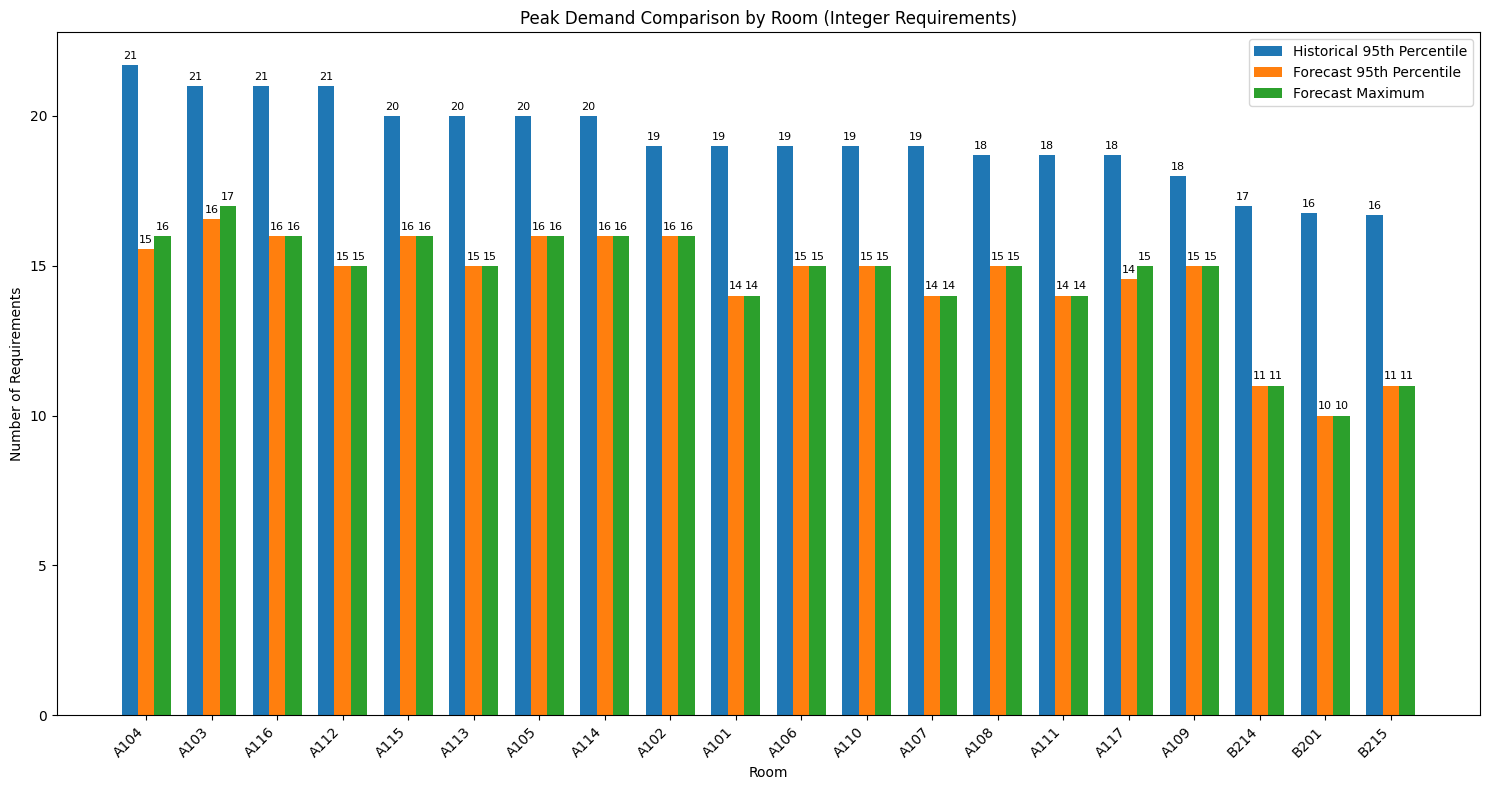

In [101]:
# Step 12: Visualize peak demand forecasts
plt.figure(figsize=(15, 8))
rooms = list(peak_forecasts.keys())
historical_peaks = [peak_forecasts[room]['historical_peak'] for room in rooms]
future_peaks = [peak_forecasts[room]['future_peak'] for room in rooms]
future_maxes = [peak_forecasts[room]['future_max'] for room in rooms]

# Sort rooms by historical peak demand
sorted_indices = np.argsort(historical_peaks)[::-1]
sorted_rooms = [rooms[i] for i in sorted_indices]
sorted_historical_peaks = [historical_peaks[i] for i in sorted_indices]
sorted_future_peaks = [future_peaks[i] for i in sorted_indices]
sorted_future_maxes = [future_maxes[i] for i in sorted_indices]

# Plot only the top 20 rooms for readability
top_n = 20
top_rooms = sorted_rooms[:top_n]
top_historical_peaks = sorted_historical_peaks[:top_n]
top_future_peaks = sorted_future_peaks[:top_n]
top_future_maxes = sorted_future_maxes[:top_n]

x = np.arange(len(top_rooms))
width = 0.25

fig, ax = plt.subplots(figsize=(15, 8))
rects1 = ax.bar(x - width, top_historical_peaks, width, label='Historical 95th Percentile')
rects2 = ax.bar(x, top_future_peaks, width, label='Forecast 95th Percentile')
rects3 = ax.bar(x + width, top_future_maxes, width, label='Forecast Maximum')

ax.set_xlabel('Room')
ax.set_ylabel('Number of Requirements')
ax.set_title('Peak Demand Comparison by Room (Integer Requirements)')
ax.set_xticks(x)
ax.set_xticklabels(top_rooms, rotation=45, ha='right')
ax.legend()

# Add value labels
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{int(height)}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "peak_demand_forecast.png"))
plt.show()

In [102]:
# Step 14: Generate staffing recommendations based on peak demand
print("\nER Staffing Recommendations Based on Peak Demand Analysis:")

staffing_output = "ER Staffing Recommendations Based on Peak Demand Analysis:\n\n"

# Compute historical and predicted statistics for each room
historical_stats = {}
predicted_stats = {}

for room in pattern_rooms:
    if room in time_series_dict:
        series = time_series_dict[room]
        historical_stats[room] = {
            'max': series.max(),
            'std': series.std()
        }
    else:
        historical_stats[room] = {'max': 0, 'std': 0}

    if room in peak_forecasts:
        future_series = peak_forecasts[room]['future_daily_totals']
        predicted_stats[room] = {
            'max': future_series.max(),
            'std': future_series.std()
        }
    else:
        predicted_stats[room] = {'max': 0, 'std': 0}

# Staffing recommendations
past_max_demand = max(total_demand[-30:])
overall_max_demand = total_demand.max()
staff_adjustment = past_max_demand / overall_max_demand if overall_max_demand > 0 else 1.0
staffing_output += f"Staff Adjustment Factor (based on max daily demand): {staff_adjustment:.2f} (adjust staff if >1 or <1)\n"
print(f"Staff Adjustment Factor (based on max daily demand): {staff_adjustment:.2f} (adjust staff if >1 or <1)")

# High peak demand rooms
high_peak_rooms = sorted(pattern_rooms, key=lambda room: max(historical_stats[room]['max'], predicted_stats[room]['max']), reverse=True)[:5]
staffing_output += "Rooms with High Peak Demands (Past or Predicted):\n"
print("Rooms with High Peak Demands (Past or Predicted):")
for room in high_peak_rooms:
    past_max = historical_stats[room]['max']
    pred_max = predicted_stats[room]['max']
    peak_line = f"- {room}: Past Max = {past_max:.1f} tasks/day, Predicted Max = {pred_max:.1f} tasks/day"
    print(peak_line)
    staffing_output += peak_line + "\n"

# High variability rooms
high_variability_rooms = sorted(pattern_rooms, key=lambda room: max(historical_stats[room]['std'], predicted_stats[room]['std']), reverse=True)[:5]
staffing_output += "\nRooms with High Variability (May Need Flexible Staffing):\n"
print("\nRooms with High Variability (May Need Flexible Staffing):")
for room in high_variability_rooms:
    past_std = historical_stats[room]['std']
    pred_std = predicted_stats[room]['std']
    var_line = f"- {room}: Past Std Dev = {past_std:.1f}, Predicted Std Dev = {pred_std:.1f}"
    print(var_line)
    staffing_output += var_line + "\n"

# Significant increase in workload
significant_increase_rooms = [
    room for room in pattern_rooms
    if predicted_stats[room]['max'] > historical_stats[room]['max'] * 1.2 and historical_stats[room]['max'] > 0
]
staffing_output += "\nRooms with Significant Predicted Workload Increases (Max Tasks Increase > 20%):\n"
print("\nRooms with Significant Predicted Workload Increases (Max Tasks Increase > 20%):")
for room in significant_increase_rooms:
    past_max = historical_stats[room]['max']
    pred_max = predicted_stats[room]['max']
    increase_line = f"- {room}: Past Max = {past_max:.1f}, Predicted Max = {pred_max:.1f} (+{(pred_max/past_max-1)*100:.1f}%)"
    print(increase_line)
    staffing_output += increase_line + "\n"

save_text_to_file("step_14_staffing_recommendations.txt", staffing_output)
print(f"All results and graphs have been saved to the folder: {output_dir}")


ER Staffing Recommendations Based on Peak Demand Analysis:
Staff Adjustment Factor (based on max daily demand): 0.92 (adjust staff if >1 or <1)
Rooms with High Peak Demands (Past or Predicted):
- B202: Past Max = 82.0 tasks/day, Predicted Max = 11.0 tasks/day
- C310: Past Max = 79.0 tasks/day, Predicted Max = 11.0 tasks/day
- C319: Past Max = 40.0 tasks/day, Predicted Max = 10.0 tasks/day
- B205: Past Max = 35.0 tasks/day, Predicted Max = 11.0 tasks/day
- B212: Past Max = 34.0 tasks/day, Predicted Max = 10.0 tasks/day

Rooms with High Variability (May Need Flexible Staffing):
- B202: Past Std Dev = 6.3, Predicted Std Dev = 1.5
- C310: Past Std Dev = 5.8, Predicted Std Dev = 1.3
- A101: Past Std Dev = 4.3, Predicted Std Dev = 1.2
- A111: Past Std Dev = 4.2, Predicted Std Dev = 0.9
- A104: Past Std Dev = 4.2, Predicted Std Dev = 1.2

Rooms with Significant Predicted Workload Increases (Max Tasks Increase > 20%):
All results and graphs have been saved to the folder: ER_Prophet_Results


In [103]:
 !zip -r ER_Prophet_Results.zip /content/ER_Prophet_Results

updating: content/ER_Prophet_Results/ (stored 0%)
updating: content/ER_Prophet_Results/peak_demand_forecast.png (deflated 23%)
updating: content/ER_Prophet_Results/daily_requirements_distribution.png (deflated 15%)
updating: content/ER_Prophet_Results/peak_demand_by_weekday.png (deflated 26%)
updating: content/ER_Prophet_Results/step_14_staffing_recommendations.txt (deflated 62%)
updating: content/ER_Prophet_Results/hourly_requirement_pattern.png (deflated 23%)
updating: content/ER_Prophet_Results/C320_forecast.png (deflated 5%)
updating: content/ER_Prophet_Results/C313_forecast.png (deflated 5%)
updating: content/ER_Prophet_Results/T2_forecast.png (deflated 10%)
updating: content/ER_Prophet_Results/A105_forecast.png (deflated 5%)
updating: content/ER_Prophet_Results/T5_forecast.png (deflated 12%)
updating: content/ER_Prophet_Results/C317_forecast.png (deflated 5%)
updating: content/ER_Prophet_Results/T4_forecast.png (deflated 7%)
updating: content/ER_Prophet_Results/B213_forecast.png 

In [104]:
# !rm -rf /content/ER_Prophet_Results